# Visualization, Exploratory Data Analysis, and Group Project Launch

## Learning goals

By the end of class, you should be able to:

- use tables and visualizations together during exploratory data analysis (EDA);
- distinguish a useful descriptive finding from an unsupported causal claim;
- identify how filtering and grouping affect a result;
- form a group of 2–3 students and define a focused analytical question; and
- leave class with initial evidence and a concrete plan for a short group project.

## Suggested class sequence

| Time | Activity |
|---|---|
| 0–5 minutes | Frame EDA as a process of asking, checking, revising, and communicating |
| 5–20 minutes | Guided visualization and EDA example |
| 20–25 minutes | Discuss what the first plots reveal—and what they do not establish |
| 25–45 minutes | **Twenty-minute group formation and data drill-down** |
| 45–60 minutes | One-minute group reports and feedback |
| Remaining time | Begin the project notebook and slide storyboard |


## Business case: How do a wholesaler's customer segments differ?

Imagine that you are advising a wholesale distributor. The company wants to understand how annual purchasing patterns differ across customer channels and regions. Your immediate task is not to build a prediction model or establish causality. It is to locate patterns, test comparisons, identify unusual customers, and decide what should be investigated next.

The UCI Wholesale Customers dataset contains 440 customer records. Spending is measured in unspecified monetary units. Important variables include:

- `Channel`: 1 represents hotel/restaurant/café customers; 2 represents retail customers;
- `Region`: 1 represents Lisbon, 2 Oporto, and 3 other regions;
- `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, and `Delicassen`: annual spending by product category.

Source: [UCI Machine Learning Repository, Wholesale Customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers).


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
customers = pd.read_csv(DATA_URL)
customers.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 1. Begin with structure, quality, and scale


In [2]:
print(f"Rows: {customers.shape[0]:,}")
print(f"Columns: {customers.shape[1]}")
customers.info()


Rows: 440
Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
spending_columns = [
    "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"
]

customers[spending_columns].describe().round(2)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,3.00,55.00,3.00,25.00,3.00,3.00
25%,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


### Discuss

1. What is one feature of the dataset you would investigate before making a chart?
2. Does the absence of `NaN` values guarantee that every row is typical or valid?
3. Which spending categories appear to contain unusually large values?


## 2. Look at one variable before comparing groups


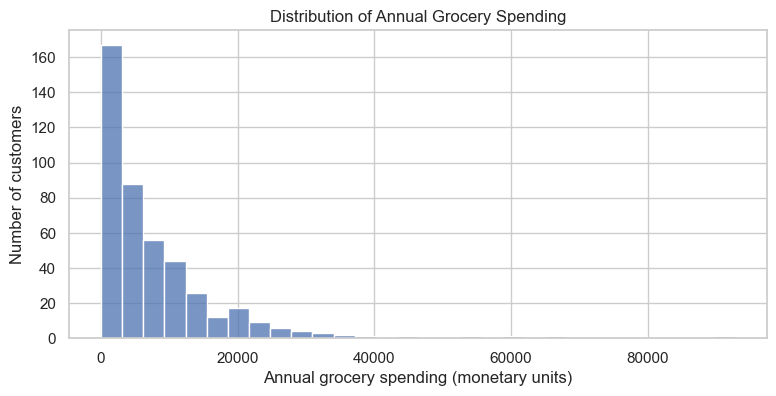

In [12]:
plt.figure(figsize=(9, 4))
sns.histplot(data=customers, x="Grocery", bins=30)
plt.title("Distribution of Annual Grocery Spending")
plt.xlabel("Annual grocery spending (monetary units)")
plt.ylabel("Number of customers");

### Interpret before moving on

- Is the distribution symmetric or skewed?
- Would the mean and median tell the same story?
- How might this shape affect comparisons between groups?


In [7]:
customers["Grocery"].agg(["mean", "median", "min", "max"]).round(2)


mean       7951.28
median     4755.50
min           3.00
max       92780.00
Name: Grocery, dtype: float64

## 3. Examine a relationship


Text(0, 0.5, 'Annual detergents/paper spending')

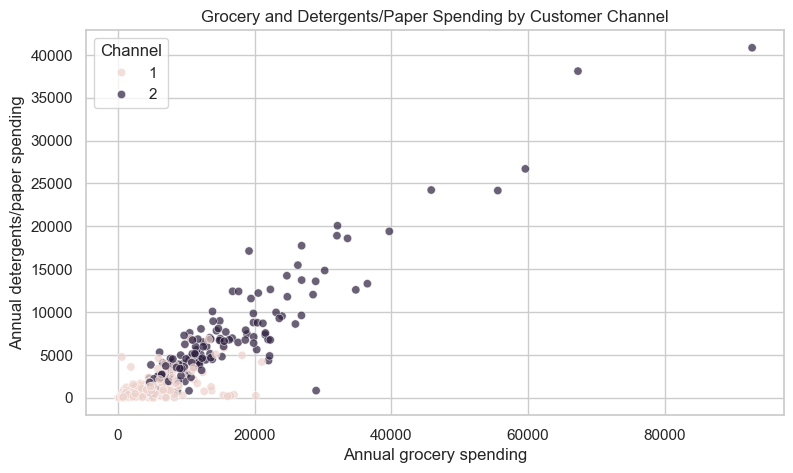

In [8]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=customers,
    x="Grocery",
    y="Detergents_Paper",
    hue="Channel",
    alpha=0.7,
)
plt.title("Grocery and Detergents/Paper Spending by Customer Channel")
plt.xlabel("Annual grocery spending")
plt.ylabel("Annual detergents/paper spending")



### Discuss

- What is the strongest visible pattern?
- Where is the graph crowded or difficult to read?
- Do the two channels occupy clearly different parts of the graph?
- Does the graph establish that grocery spending *causes* detergents/paper spending?


## 4. Use `groupby` to support—or complicate—the graph


In [9]:
channel_summary = (
    customers.groupby("Channel")
    .agg(
        number_of_customers=("Grocery", "size"),
        median_fresh=("Fresh", "median"),
        median_grocery=("Grocery", "median"),
        median_detergents_paper=("Detergents_Paper", "median"),
    )
)

channel_summary.round(2)


,number_of_customers,median_fresh,median_grocery,median_detergents_paper
Channel,,,,
1,298,9581.5,2684.0,385.5
2,142,5993.5,12390.0,5614.5


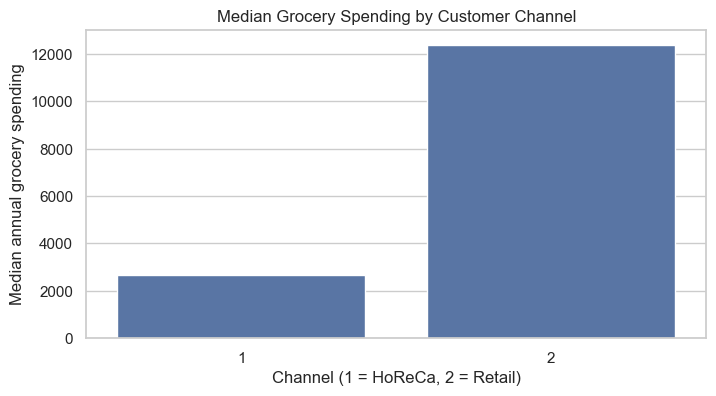

In [10]:
plt.figure(figsize=(8, 4))
sns.barplot(data=customers, x="Channel", y="Grocery", estimator="median", errorbar=None)
plt.title("Median Grocery Spending by Customer Channel")
plt.xlabel("Channel (1 = HoReCa, 2 = Retail)")
plt.ylabel("Median annual grocery spending")
plt.show()


### The EDA turn

A simple comparison by channel may be misleading because the channels can contain different regional mixes and unusually large customers. EDA is iterative: an apparent answer should produce a better question.

> **Next question:** Does the channel comparison remain similar when we examine each region separately?


In [11]:
customers.groupby(["Region", "Channel"]).agg(
    number_of_customers=("Grocery", "size"),
    median_grocery=("Grocery", "median"),
    median_fresh=("Fresh", "median"),
).round(2)


number_of_customers  median_grocery  median_fresh
Region Channel                                                   
1      1                         59          2576.0        8656.0
       2                         18         16106.0        2926.0
2      1                         28          3352.0        9787.0
       2                         19         12469.0        6468.0
3      1                        211          2642.0        9612.0
       2                        105         12121.0        7362.0

## Explore Further: EDA and Visualization Resources

Exploratory data analysis is an iterative process. Do not stop after producing the first graph that appears to answer your question. Try different graph types, examine important subgroups, compare means with medians, investigate unusual observations, and consider whether a second variable changes the apparent relationship.

Seaborn includes many useful tools beyond the functions demonstrated in class. Your group is encouraged to explore its examples and documentation. Experimentation is welcome, but every visualization should have a clear analytical purpose and should remain readable.

### Seaborn resources

- [Seaborn tutorial](https://seaborn.pydata.org/tutorial.html): overview of Seaborn’s major plotting tools.
- [Visualizing distributions](https://seaborn.pydata.org/tutorial/distributions.html): histograms, density plots, and empirical distributions.
- [Visualizing categorical data](https://seaborn.pydata.org/tutorial/categorical.html): bar plots, box plots, violin plots, and categorical comparisons.
- [Visualizing statistical relationships](https://seaborn.pydata.org/tutorial/relational.html): scatter plots, line plots, `hue`, `style`, and faceting.
- [Seaborn example gallery](https://seaborn.pydata.org/examples/index.html): complete examples that can be adapted to your dataset.

When adapting an example, make sure you understand what each argument does. A more complicated graph is not necessarily a more informative graph.

### EDA and visualization readings

- Wes McKinney, *Python for Data Analysis*, 3rd edition:
  - [Chapter 7: Data Cleaning and Preparation](https://www.oreilly.com/library/view/python-for-data/9781098104023/ch07.html)
  - [Chapter 9: Plotting and Visualization](https://wesmckinney.com/book/plotting-and-visualization)
  - [Chapter 10: Data Aggregation and Group Operations](https://wesmckinney.com/book/data-aggregation)

- Claus O. Wilke, *Fundamentals of Data Visualization*:
  - [Complete book information and contents](https://www.oreilly.com/library/view/fundamentals-of-data/9781492031079/)
  - Particularly useful for choosing graph types, using color carefully, displaying distributions, and avoiding misleading visualizations.



## Small-Group Exploratory Data Analysis Project

You will work in a group of **2–3 students** to conduct an exploratory analysis of a dataset selected by your group. Each group should work with a different dataset or pursue a substantially different question.

The goal is not to prove a predetermined claim. Your group should use filtering, grouping, summary statistics, and visualization to discover patterns, revise questions, identify limitations, and communicate what you learned.

### Project products

Each group will submit:

1. A short, reproducible Jupyter notebook containing the analysis.
2. A presentation of **3-6 slides** summarizing the question, evidence, findings, limitations, and next steps.

Every group member should contribute to the analysis and be prepared to explain the code, visualizations, and conclusions.

---

## Choosing a dataset

Your group may choose a dataset connected to business, economics, finance, public policy, culture, education, health, labor, or another approved area.

A suitable dataset should:

- be available as a CSV file or another format that pandas can easily read;
- contain enough rows and variables to support meaningful comparisons;
- include at least one numerical variable;
- include at least one useful category, group, region, or time variable;
- have a clear source and enough documentation to interpret its columns;
- allow your group to formulate a focused descriptive question;
- avoid sensitive personal information; and
- be manageable within the available project time.

Avoid selecting a dataset merely because it is large. A smaller, clearly documented dataset is usually better than a large dataset whose variables are difficult to interpret.

### Possible data sources

- UCI Machine Learning Repository
- FRED economic data
- World Bank Open Data
- Data.gov
- NYC Open Data
- Census data
- Bureau of Labor Statistics
- A documented dataset from a reputable research organization
- A dataset supplied by a group member, with instructor approval

### Dataset proposal

Before beginning the full analysis, record the following:

**Group members:**

**Dataset title:**

**Dataset source and URL:**

**Unit of observation:**  
What does one row represent?

**Important variables:**

**Initial research question:**

**Why this question matters:**

**Possible limitation of the dataset:**

---

## Twenty-Minute Group and Dataset Sprint

Use the first 20 minutes to form your group, identify a dataset, and establish a workable analytical direction.

| Minutes | Required action |
|---|---|
| 0–4 | Form a group of 2–3 students and assign initial roles |
| 4–8 | Identify one or two possible datasets |
| 8–12 | Inspect the rows, columns, data types, and missing values |
| 12–16 | Write a focused descriptive question and identify the relevant variables |
| 16–20 | Produce one initial table or visualization and identify the next analytical step |



### End-of-sprint report

At the end of the sprint, your group should be ready to give a one-minute report:

> We are investigating **[question]** using **[dataset]**. One row represents **[unit of observation]**. Our initial exploration suggests **[tentative pattern]**. A possible complication is **[limitation or alternative explanation]**. Our next step is to **[specific filter, groupby, comparison, or visualization]**.

The initial finding may change as your group continues working. Revising a question in response to evidence is part of exploratory analysis.

---

## Notebook Expectations

Your final notebook should be concise, readable, and reproducible. It should include the following sections.

### 1. Question and context

State a focused descriptive question and briefly explain why it matters.

### 2. Data source

Identify the dataset’s creator or publisher, provide a link, and explain what one row represents.

### 3. Data inspection

Examine:

- the number of rows and columns;
- column names and data types;
- missing values;
- relevant summary statistics; and
- possible errors, unusual values, or limitations.

### 4. Data preparation

Document any filtering, missing-value treatment, new variables, or other changes. Explain why each important change was made.

### 5. Grouped analysis

Include at least one meaningful use of `groupby`. Use an appropriate summary such as a count, mean, median, minimum, maximum, or several summaries with `.agg()`.

### 6. Visual analysis

Include **two or three purposeful visualizations**. Each visualization should have:

- a descriptive title;
- clearly labeled axes;
- an appropriate graph type;
- readable legends or category labels; and
- a short written interpretation.

### 7. Findings

Present two or three findings supported by specific tables or visualizations.

### 8. Limitations

Identify at least one important limitation, possible confounding variable, missing perspective, or alternative explanation.

### 9. Next step

Propose one realistic extension, additional variable, comparison, or new data source.

Before submitting, restart the kernel and run every cell from top to bottom.

---

## Presentation Expectations

Prepare a presentation of **3-6 slides**. A strong five-slide structure is:

1. **Title, team, and research question**
2. **Dataset, source, and unit of observation**
3. **First finding and visualization**
4. **Limitations or complications**
5. **Conclusion and next step**

Slides should emphasize evidence and interpretation rather than screenshots of code. Every chart should have a descriptive title, readable labels, and a clear takeaway.

---

# Project Rubric

Each category is scored on a four-point scale. There are **5 categories and 20 possible points**.

| Expectation | 4 — Strong | 3 — Proficient | 2 — Developing | 1 — Incomplete |
|---|---|---|---|---|
| **Question and dataset understanding** | Presents a focused, meaningful question that fits the dataset. Clearly explains the source, unit of observation, important variables, and why the question matters. | Presents a clear, answerable question and correctly describes the dataset, with only minor omissions. | Question is broad or only partially answerable, or the description of the dataset lacks important context. | Question is missing, unclear, or cannot be addressed with the selected dataset. |
| **Data preparation and pandas analysis** | Carefully checks data types, missing values, and unusual observations. Uses selection, filtering, `groupby`, and summary methods correctly and purposefully. | Completes the necessary data checks and uses appropriate pandas methods with only minor problems. | Performs some preparation and analysis, but important checks or methods are missing, unclear, or incorrect. | Analysis is substantially incomplete or contains errors that invalidate major results. |
| **Visualizations and evidence** | Includes two or three well-chosen, readable visualizations. Titles, labels, tables, and graphs clearly support the group’s findings. | Includes appropriate visualizations and supporting evidence with only minor design or labeling problems. | Visualizations are present but have problems with relevance, readability, labeling, or connection to the question. | Visualizations are missing, misleading, unreadable, or disconnected from the analysis. |
| **Interpretation, limitations, and next steps** | Makes precise claims supported by the analysis, avoids causal overstatement, identifies meaningful limitations or alternative explanations, and proposes a specific next step. | Findings are supported by the analysis and include a reasonable limitation and next step. | Interpretation is limited, somewhat overstated, or weakly connected to the evidence; limitations or next steps need development. | Conclusions are unsupported or inaccurate, and limitations and next steps are missing. |
| **Communication and collaboration** | Notebook is organized, reproducible, and clearly written. Slides present a coherent analytical story, and every member demonstrates meaningful participation and understanding. | Notebook and presentation communicate the analysis clearly, run with few or no errors, and show generally balanced participation. | Notebook or presentation is difficult to follow, contains reproducibility problems, or reflects uneven participation. | Work is substantially incomplete, cannot be reproduced, or depends almost entirely on one group member. |

## Score interpretation

| Total | General description |
|---|---|
| 18–20 | Strong, polished exploratory analysis |
| 15–17 | Proficient analysis with minor areas for improvement |
| 11–14 | Developing analysis that needs revision |
| 5–10 | Incomplete analysis requiring substantial revision |